# 02 - Preparación de los datos

En este cuaderno se realiza la preparación del Rossmann Store Sales Dataset para construir la serie de tiempo de ventas y dejar los datos listos para el análisis de estacionalidad y los modelos ARIMA, Prophet y LSTM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("../01_data/train.csv")
store = pd.read_csv("../01_data/store.csv")
test = pd.read_csv("../01_data/test.csv")

In [3]:
df = train.merge(store, on="Store", how="left")
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,"1,270.00",9.00,"2,008.00",0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,11.00,"2,007.00",1,13.00,"2,010.00","Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,"14,130.00",12.00,"2,006.00",1,14.00,"2,011.00","Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,9.00,"2,009.00",0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,"29,910.00",4.00,"2,015.00",0,NaN,NaN,NaN


In [4]:
resumen_inicial = pd.DataFrame({
    "Dataframe": ["df"],
    "Filas": [df.shape[0]],
    "Columnas": [df.shape[1]],
    "Valores nulos": [df.isnull().sum().sum()]
})

resumen_inicial

,Dataframe,Filas,Columnas,Valores nulos
0,df,1017209,18,2173431


## Conversión y organización temporal

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

In [6]:
df[["Date", "Year", "Month", "Day", "WeekOfYear"]].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [7]:
rango_fechas = pd.DataFrame({
    "Fecha mínima": [df["Date"].min()],
    "Fecha máxima": [df["Date"].max()]
})

rango_fechas

,Fecha mínima,Fecha máxima
0,2013-01-01,2015-07-31


## Limpieza de registros para modelado

In [8]:
df_modelo = df.copy()

df_modelo = df_modelo[df_modelo["Open"] == 1]
df_modelo = df_modelo[df_modelo["Sales"] > 0]

df_modelo.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,"1,270.00",9.00,"2,008.00",0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,11.00,"2,007.00",1,13.00,"2,010.00","Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,"14,130.00",12.00,"2,006.00",1,14.00,"2,011.00","Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,9.00,"2,009.00",0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,"29,910.00",4.00,"2,015.00",0,NaN,NaN,NaN,2015,7,31,31


In [9]:
resumen_limpieza = pd.DataFrame({
    "Dataset": ["Antes de limpieza", "Después de limpieza"],
    "Filas": [df.shape[0], df_modelo.shape[0]],
    "Columnas": [df.shape[1], df_modelo.shape[1]]
})

resumen_limpieza

,Dataset,Filas,Columnas
0,Antes de limpieza,1017209,22
1,Después de limpieza,844338,22


## Tratamiento de valores faltantes

In [10]:
nulos_modelo = pd.DataFrame({
    "Columna": df_modelo.columns,
    "Valores nulos": df_modelo.isnull().sum().values
})

nulos_modelo[nulos_modelo["Valores nulos"] > 0]

,Columna,Valores nulos
11,CompetitionDistance,2186
12,CompetitionOpenSinceMonth,268600
13,CompetitionOpenSinceYear,268600
15,Promo2SinceWeek,423292
16,Promo2SinceYear,423292
17,PromoInterval,423292


In [11]:
df_modelo["CompetitionDistance"] = df_modelo["CompetitionDistance"].fillna(df_modelo["CompetitionDistance"].median())

df_modelo["CompetitionOpenSinceMonth"] = df_modelo["CompetitionOpenSinceMonth"].fillna(0)
df_modelo["CompetitionOpenSinceYear"] = df_modelo["CompetitionOpenSinceYear"].fillna(0)

df_modelo["Promo2SinceWeek"] = df_modelo["Promo2SinceWeek"].fillna(0)
df_modelo["Promo2SinceYear"] = df_modelo["Promo2SinceYear"].fillna(0)
df_modelo["PromoInterval"] = df_modelo["PromoInterval"].fillna("No aplica")

In [20]:
nulos_despues = pd.DataFrame({
    "Columna": df_modelo.columns,
    "Valores nulos": df_modelo.isnull().sum().values
})

nulos_restantes = nulos_despues[nulos_despues["Valores nulos"] > 0]

if nulos_restantes.empty:
    print("No quedan valores nulos en el dataset preparado.")
else:
    display(nulos_restantes)

No quedan valores nulos en el dataset preparado.


## Construcción de la serie temporal

In [13]:
serie_ventas = df_modelo.groupby("Date")["Sales"].sum().reset_index()
serie_ventas = serie_ventas.sort_values("Date")

serie_ventas.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [14]:
serie_ventas.tail()

,Date,Sales
937,2015-07-27,10707292
938,2015-07-28,9115073
939,2015-07-29,8499962
940,2015-07-30,8798854
941,2015-07-31,10109742


In [15]:
resumen_serie = pd.DataFrame({
    "Fecha inicial": [serie_ventas["Date"].min()],
    "Fecha final": [serie_ventas["Date"].max()],
    "Total de días": [serie_ventas.shape[0]],
    "Venta promedio diaria": [serie_ventas["Sales"].mean()],
    "Venta mínima diaria": [serie_ventas["Sales"].min()],
    "Venta máxima diaria": [serie_ventas["Sales"].max()]
})

resumen_serie

,Fecha inicial,Fecha final,Total de días,Venta promedio diaria,Venta mínima diaria,Venta máxima diaria
0,2013-01-01,2015-07-31,942,"6,234,798.96",97235,15623548


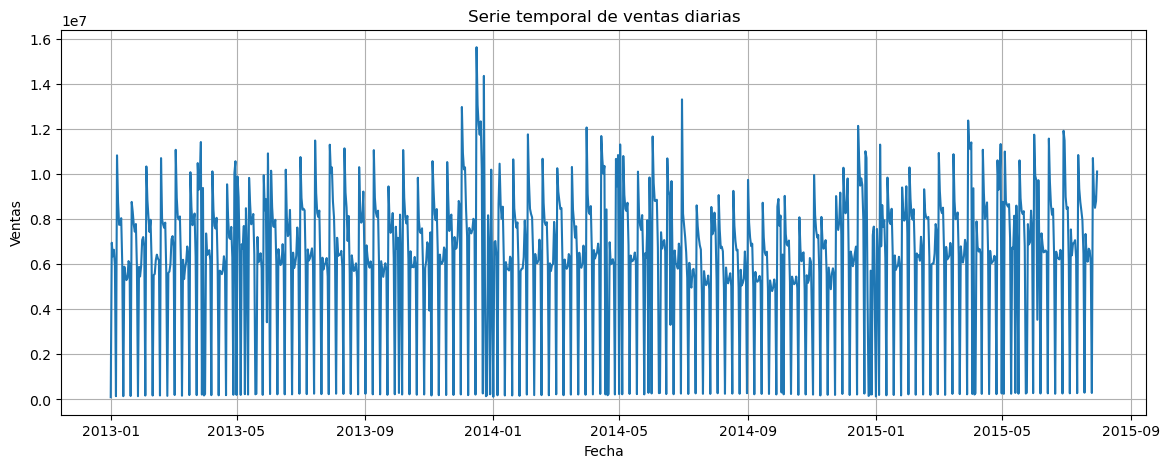

In [16]:
plt.figure(figsize=(14,5))
plt.plot(serie_ventas["Date"], serie_ventas["Sales"])
plt.title("Serie temporal de ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

## Preparación de datos para Prophet y LSTM

In [17]:
serie_prophet = serie_ventas.rename(columns={
    "Date": "ds",
    "Sales": "y"
})

serie_prophet.head()

,ds,y
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [18]:
serie_lstm = serie_ventas.copy()
serie_lstm.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [19]:
serie_ventas.to_csv("../01_data/serie_ventas_preparada.csv", index=False)
serie_prophet.to_csv("../01_data/serie_prophet.csv", index=False)
serie_lstm.to_csv("../01_data/serie_lstm.csv", index=False)

## Serie temporal con variables externas

Se construye una serie diaria de ventas integrando variables externas del Rossmann Store Sales Dataset. Estas variables serán usadas en los modelos Prophet y LSTM.

In [22]:
df_externo = df.copy()

df_externo["Date"] = pd.to_datetime(df_externo["Date"])

df_externo["StateHolidayFlag"] = df_externo["StateHoliday"].apply(
    lambda x: 0 if x == "0" or x == 0 else 1
)

In [23]:
serie_externa = df_externo.groupby("Date").agg({
    "Sales": "sum",
    "Promo": "mean",
    "SchoolHoliday": "max",
    "StateHolidayFlag": "max",
    "Open": "mean",
    "Promo2": "mean",
    "CompetitionDistance": "mean"
}).reset_index()

serie_externa = serie_externa.sort_values("Date")
serie_externa.head()

,Date,Sales,Promo,SchoolHoliday,StateHolidayFlag,Open,Promo2,CompetitionDistance
0,2013-01-01,97235,0.00,1,1,0.02,0.51,"5,409.74"
1,2013-01-02,6949829,0.00,1,0,1.00,0.51,"5,404.90"
2,2013-01-03,6347820,0.00,1,0,0.99,0.51,"5,404.90"
3,2013-01-04,6638954,0.00,1,0,0.99,0.51,"5,404.90"
4,2013-01-05,5951593,0.00,1,0,0.99,0.51,"5,404.90"


In [24]:
serie_externa["CompetitionDistance"] = serie_externa["CompetitionDistance"].fillna(
    serie_externa["CompetitionDistance"].median()
)

In [25]:
resumen_serie_externa = pd.DataFrame({
    "Fecha inicial": [serie_externa["Date"].min()],
    "Fecha final": [serie_externa["Date"].max()],
    "Total de días": [serie_externa.shape[0]],
    "Venta promedio diaria": [serie_externa["Sales"].mean()],
    "Promoción promedio": [serie_externa["Promo"].mean()],
    "Apertura promedio": [serie_externa["Open"].mean()]
})

resumen_serie_externa

,Fecha inicial,Fecha final,Total de días,Venta promedio diaria,Promoción promedio,Apertura promedio
0,2013-01-01,2015-07-31,942,"6,234,798.96",0.38,0.83


In [26]:
serie_externa.to_csv("../01_data/serie_externa_preparada.csv", index=False)

Con esta preparación se obtiene una serie temporal diaria que integra variables externas del dataset, como promociones, festivos, apertura de tiendas, promoción extendida y distancia de competencia.

## Conclusión

En esta fase se prepararon los datos para el análisis de series de tiempo. Se integraron los datos históricos de ventas con las variables externas de las tiendas, se convirtió la columna `Date` a formato temporal, se crearon variables de tiempo y se limpiaron registros de tiendas cerradas o sin ventas.

También se trataron valores faltantes en variables externas y se construyó la serie temporal diaria de ventas. Finalmente, se dejaron preparados los datos para los modelos Prophet y LSTM.